In [ ]:
#Monthly Job Postings for Top Data Jobs in the US
import ast
import pandas as pd
from datasets import load_dataset
import seaborn as sns
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
#Investigate Data Analyst and Data Scientist role in the Philipines
#First, get a copy of dataframe filtered to data analyst and data scientist roles in the philippines
job_titles = ['Data Analyst', 'Data Scientist']
df_DSDA_PH = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'Philippines')].copy()
#Evaluate the job_skills using explode function
df_DSDA_PH = df_DSDA_PH.explode('job_skills')
df_DSDA_PH['job_location'] = df_DSDA_PH['job_location'].apply(lambda x: x.split()[0])
df_DSDA_PH['job_location'] = df_DSDA_PH['job_location'].apply(lambda x: x.replace(',',''))
df_DSDA_PH = df_DSDA_PH.dropna(subset='salary_year_avg')


In [3]:
#We want to know where are these job posting located the most.
df_location = df_DSDA_PH.groupby(['job_title_short', 'job_location']).size()
df_location = df_location.sort_values(ascending=False).reset_index(name='counts')

df_DA_location = df_location[df_location['job_title_short'] == 'Data Analyst']
#df_DA_location  = df_DA_location.drop(df_DA_location.index[df_DA_location['job_location'].isin(['Philippines', 'Anywhere'])]) 

df_DS_location = df_location[df_location['job_title_short'] == 'Data Scientist']
#df_DS_location  = df_DS_location.drop(df_DS_location.index[df_DS_location['job_location'].isin(['Philippines', 'Anywhere'])])

df_DS_location

,job_title_short,job_location,counts
2,Data Scientist,Biñan,18
4,Data Scientist,Philippines,14
5,Data Scientist,Manila,11
7,Data Scientist,Mandaluyong,6
10,Data Scientist,Pasig,5
11,Data Scientist,Makati,4


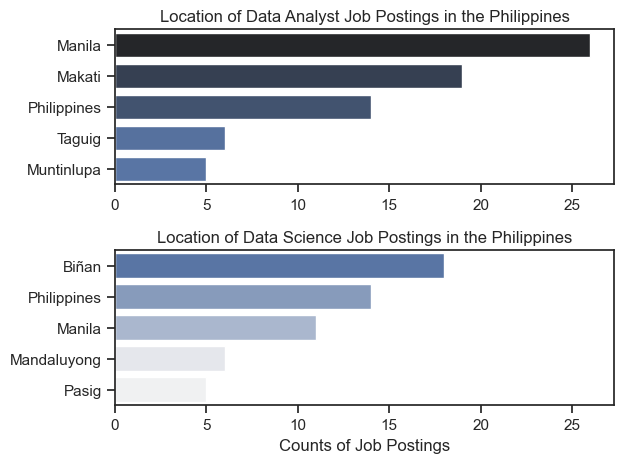

In [5]:
#plot gathered tables
sns.set_theme(style='ticks')
fig,ax = plt.subplots(2,1)
sns.barplot(data=df_DA_location.head(5), x='counts', y='job_location', hue='counts', palette='dark:b_r', ax=ax[0], legend=False)
ax[0].set_title('Location of Data Analyst Job Postings in the Philippines')
ax[0].set_ylabel('')
ax[0].set_xlabel('')

sns.barplot(data=df_DS_location.head(5), x='counts', y='job_location', hue='counts', palette='light:b', ax=ax[1], legend=False)
ax[1].set_title('Location of Data Science Job Postings in the Philippines')
ax[1].set_ylabel('')
ax[1].set_xlabel('Counts of Job Postings')
ax[1].set_xlim(ax[0].get_xlim())

plt.tight_layout()

#needs some improvements. Remove "Metro Manila, Philippines" to make the graph more compact.
#Daming Data Analyst work na located sa Manila!!!!!
#GRAPH CHANGES UPON REMOVAL OF salary_year_avg NA's!!!, consider adapting those NA's or completely drop them.

Text(0.5, 12.44444444444443, '')

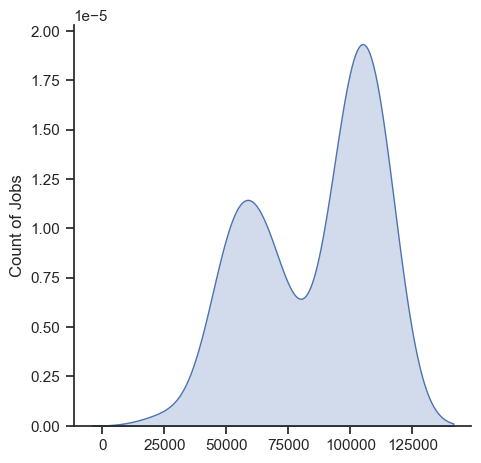

In [6]:
#Check what are the mean/median salaries of these top 5 locations.

df_DA_PH = df_DSDA_PH[df_DSDA_PH['job_title_short'] == 'Data Analyst']

sns.displot(data=df_DA_PH['salary_year_avg'], kind='kde', fill=True)
plt.ylabel('Count of Jobs')
plt.xlabel('')

#according to chatgpt, this distribution is a bimodal distribution and usually in this case, median is a better representation than mean.
#since this distribution has 2 peaks, there exist 2 salary groups (most likely junior and senior roles)
#dive deeper to get better representation (get visualization for junior and senior roles)

In [7]:
df_DSDA_PH[df_DSDA_PH['job_title_short'] == 'Data Analyst']

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
115695,Data Analyst,Data Analyst (Procurement/Logistics),Tarlac,via Ai-Jobs.net,Full-time,False,Philippines,2023-08-25 08:14:55,False,False,Philippines,year,111175.0,NaN,Pilmico Foods Corporation,excel,"{'analyst_tools': ['excel', 'tableau']}"
115695,Data Analyst,Data Analyst (Procurement/Logistics),Tarlac,via Ai-Jobs.net,Full-time,False,Philippines,2023-08-25 08:14:55,False,False,Philippines,year,111175.0,NaN,Pilmico Foods Corporation,tableau,"{'analyst_tools': ['excel', 'tableau']}"
147342,Data Analyst,Data Management Assistant ( Stay-in Set-up),Tarlac,via Ai-Jobs.net,Full-time,False,Philippines,2023-02-07 08:16:41,False,False,Philippines,year,50400.0,NaN,Pilmico Foods Corporation,None,None
166142,Data Analyst,"Data Analyst, Customer Experience",Manila,via Ai-Jobs.net,Full-time,False,Philippines,2023-03-03 15:19:36,True,False,Philippines,year,111175.0,NaN,Dialpad,sql,"{'other': ['flow'], 'programming': ['sql']}"
166142,Data Analyst,"Data Analyst, Customer Experience",Manila,via Ai-Jobs.net,Full-time,False,Philippines,2023-03-03 15:19:36,True,False,Philippines,year,111175.0,NaN,Dialpad,flow,"{'other': ['flow'], 'programming': ['sql']}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777328,Data Analyst,Data Product Manager,Makati,via Ai-Jobs.net,Full-time,False,Philippines,2023-07-04 05:15:58,False,False,Philippines,year,64800.0,NaN,Angkas,sql,"{'analyst_tools': ['tableau', 'looker', 'power..."
777328,Data Analyst,Data Product Manager,Makati,via Ai-Jobs.net,Full-time,False,Philippines,2023-07-04 05:15:58,False,False,Philippines,year,64800.0,NaN,Angkas,tableau,"{'analyst_tools': ['tableau', 'looker', 'power..."
777328,Data Analyst,Data Product Manager,Makati,via Ai-Jobs.net,Full-time,False,Philippines,2023-07-04 05:15:58,False,False,Philippines,year,64800.0,NaN,Angkas,looker,"{'analyst_tools': ['tableau', 'looker', 'power..."
777328,Data Analyst,Data Product Manager,Makati,via Ai-Jobs.net,Full-time,False,Philippines,2023-07-04 05:15:58,False,False,Philippines,year,64800.0,NaN,Angkas,power bi,"{'analyst_tools': ['tableau', 'looker', 'power..."


In [8]:
#look at top 5 companies who offers high salary based on salary_year_avg
df_company = df_DSDA_PH.groupby(['job_title_short', 'company_name'])['salary_year_avg'].mean()
df_company = df_company.reset_index(name='salary').sort_values(by='salary', ascending=False)
df_company_DA = df_company[df_company['job_title_short'] == 'Data Analyst']
df_company_DA
df_company_DS = df_company[df_company['job_title_short'] == 'Data Scientist']
df_company_DS
#take note that this uses php as currency

,job_title_short,company_name,salary
28,Data Scientist,World Vision,164000.0
22,Data Scientist,InDebted,139216.0
24,Data Scientist,Publicis Groupe,109500.0
19,Data Scientist,Devex,109500.0
20,Data Scientist,FactSet,99179.5
26,Data Scientist,Smartly.io,79200.0
25,Data Scientist,Security Bank,72000.0
27,Data Scientist,Western Digital,69962.5
21,Data Scientist,IQVIA,64800.0
23,Data Scientist,NielsenIQ,61920.0


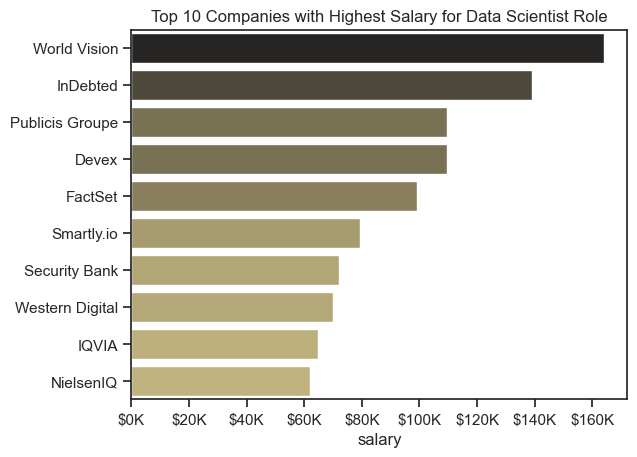

In [9]:
sns.barplot(data=df_company_DS, x='salary', y='company_name', hue='salary', palette='dark:y_r', legend=False)
plt.title('Top 10 Companies with Highest Salary for Data Scientist Role')
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
#in fact, 10 lang silang nag-o-offer ng data scientist role lololol